# Unified EDA and Schema Harmonization
Loading 2015-2019 datasets, renaming columns to a unified schema, and concatenating them.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_2015 = pd.read_csv('../data/raw/2015.csv')
df_2016 = pd.read_csv('../data/raw/2016.csv')
df_2017 = pd.read_csv('../data/raw/2017.csv')
df_2018 = pd.read_csv('../data/raw/2018.csv')
df_2019 = pd.read_csv('../data/raw/2019.csv')

## 1. Schema Harmonization

In [2]:
schema_15_16 = {
    'Country': 'country', 'Happiness Score': 'happiness_score', 
    'Economy (GDP per Capita)': 'gdp', 'Family': 'family', 
    'Health (Life Expectancy)': 'health', 'Freedom': 'freedom', 
    'Trust (Government Corruption)': 'corruption', 'Generosity': 'generosity'
}
schema_17 = {
    'Country': 'country', 'Happiness.Score': 'happiness_score', 
    'Economy..GDP.per.Capita.': 'gdp', 'Family': 'family', 
    'Health..Life.Expectancy.': 'health', 'Freedom': 'freedom', 
    'Trust..Government.Corruption.': 'corruption', 'Generosity': 'generosity'
}
schema_18_19 = {
    'Country or region': 'country', 'Score': 'happiness_score', 
    'GDP per capita': 'gdp', 'Social support': 'family', 
    'Healthy life expectancy': 'health', 'Freedom to make life choices': 'freedom', 
    'Perceptions of corruption': 'corruption', 'Generosity': 'generosity'
}

cols_to_keep = ['country', 'happiness_score', 'gdp', 'family', 'health', 'freedom', 'corruption', 'generosity']

dfs = [df_2015, df_2016, df_2017, df_2018, df_2019]
schemas = [schema_15_16, schema_15_16, schema_17, schema_18_19, schema_18_19]
years = [2015, 2016, 2017, 2018, 2019]

processed_dfs = []
for df, schema, year in zip(dfs, schemas, years):
    df_clean = df.rename(columns=schema)
    df_clean = df_clean[cols_to_keep].copy()
    df_clean['year'] = year
    processed_dfs.append(df_clean)

df_unified = pd.concat(processed_dfs, ignore_index=True)

## 2. Missing Values Imputation

In [3]:
print("Missing values before:", df_unified.isnull().sum().sum())
median_corruption_2018 = df_unified[df_unified['year'] == 2018]['corruption'].median()
df_unified['corruption'] = df_unified['corruption'].fillna(median_corruption_2018)
print("Missing values after:", df_unified.isnull().sum().sum())

Missing values before: 1
Missing values after: 0


## 3. Exploratory Data Analysis
Let's look at the correlation and distributions.

In [4]:
df_unified.describe()

,happiness_score,gdp,family,health,freedom,corruption,generosity,year
count,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000,782.000000
mean,5.379018,0.916047,1.078392,0.612416,0.411091,0.125380,0.218576,2016.993606
std,1.127456,0.407340,0.329548,0.248309,0.152880,0.105760,0.122321,1.417364
min,2.693000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2015.000000
25%,4.509750,0.606500,0.869363,0.440183,0.309768,0.054250,0.130000,2016.000000
50%,5.322000,0.982205,1.124735,0.647310,0.431000,0.090905,0.201982,2017.000000
75%,6.189500,1.236187,1.327250,0.808000,0.531000,0.155861,0.278832,2018.000000
max,7.769000,2.096000,1.644000,1.141000,0.724000,0.551910,0.838075,2019.000000


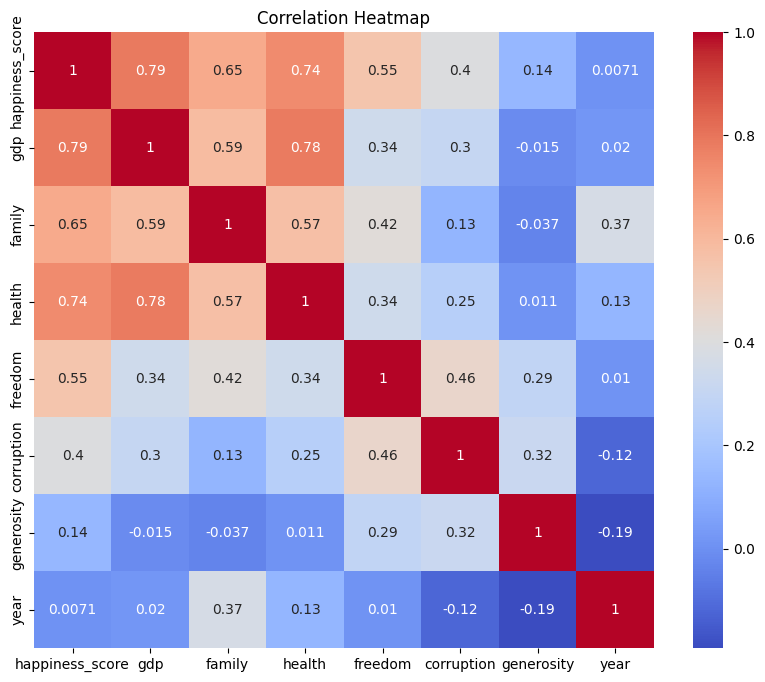

In [5]:
numeric_cols = df_unified.select_dtypes(include=[np.number])
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

## 4. Export to Processed

In [6]:
df_unified.to_csv('../data/processed/unified_happiness.csv', index=False)
print("Shape of final dataset:", df_unified.shape)
df_unified.head()

Shape of final dataset: (782, 9)


,country,happiness_score,gdp,family,health,freedom,corruption,generosity,year
0,Switzerland,7.587,1.39651,1.34951,0.94143,0.66557,0.41978,0.29678,2015
1,Iceland,7.561,1.30232,1.40223,0.94784,0.62877,0.14145,0.43630,2015
2,Denmark,7.527,1.32548,1.36058,0.87464,0.64938,0.48357,0.34139,2015
3,Norway,7.522,1.45900,1.33095,0.88521,0.66973,0.36503,0.34699,2015
4,Canada,7.427,1.32629,1.32261,0.90563,0.63297,0.32957,0.45811,2015
